In [1]:
# Install the core Hugging Face libraries
#!pip install -q transformers[torch] datasets evaluate accelerate peft

import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")


Using MPS (Apple Silicon GPU)


In [2]:
from transformers import pipeline

base_model_checkpoint = "distilbert-base-uncased"

# Load the base (pre-fine-tuned) DistilBERT as a sentiment classifier for comparison
base_classifier = pipeline(
    "sentiment-analysis",
    model=base_model_checkpoint,
    tokenizer=base_model_checkpoint,
    device=device
)

# Test the base model on a domain-specific tweet before fine-tuning
before_review = "This Browns quarterback can't throw passes to save his life"
base_output   = base_classifier(before_review)[0]

print(f"Running on: {device}")
print("Tweet:", before_review)
print("Base model output:", base_output)

# NOTE: Base DistilBERT sentiment labels — LABEL_0 = Negative, LABEL_1 = Positive

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Device set to use mps


Running on: mps
Tweet: This Browns quarterback can't throw passes to save his life
Base model output: {'label': 'LABEL_1', 'score': 0.5389005541801453}


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load NFL sentiment dataset
sentiment_df = pd.read_csv('/Users/alecxszhang/Desktop/Stat 359/student/Final_Project/nfl_sentiments.csv')

# Select relevant columns and drop rows with missing values
df = sentiment_df[['text', 'sentiment']].dropna()

# Keep only the three main sentiment categories
# Removes rare classes that cause the "least populated class" stratification error
valid_sentiments = ['neutral', 'negative', 'positive']
df = df[df['sentiment'].isin(valid_sentiments)]

# First split: carve out 20% as the held-out test set
# Stratify to preserve sentiment distribution across all splits
train_val, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['sentiment']
)

# Second split: divide remaining 80% into 60% train / 20% validation
# (test_size=0.25 of 80% = 20% of total)
train_df, val_df = train_test_split(
    train_val, test_size=0.25, random_state=42, stratify=train_val['sentiment']
)

# Verify split sizes and class balance
print("Value counts after filtering:")
print(df['sentiment'].value_counts())
print("-" * 30)
print(f"Training set:   {len(train_df)} rows")
print(f"Validation set: {len(val_df)} rows")
print(f"Testing set:    {len(test_df)} rows")

Value counts after filtering:
sentiment
neutral     2235
negative    1757
positive    1161
Name: count, dtype: int64
------------------------------
Training set:   3091 rows
Validation set: 1031 rows
Testing set:    1031 rows


In [4]:
# Map sentiment strings to integer IDs for the model
label2id = {"negative": 0, "neutral": 1, "positive": 2}
id2label = {v: k for k, v in label2id.items()}

# Add integer label column to each split in-place
for split in [train_df, val_df, test_df]:
    split["label"] = split["sentiment"].map(label2id)

print("Label mapping:", label2id)
print(train_df[["text", "sentiment", "label"]].head())

Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}
                                                   text sentiment  label
4897  Fancy destroying the famous One Ring on your o...   neutral      1
1260  Police Union Urges Officers To Protest Miami D...   neutral      1
2047  Sean Payton compared Broncos wide receiver Dev...   neutral      1
722   #Jets fans may not be pleased with Aaron Rodge...  negative      0
2025  Whatever you need fundraising for GiveSendGo i...  positive      2


In [5]:
from transformers import AutoTokenizer
from datasets import Dataset

# Load the tokenizer matching the base model checkpoint
tokenizer = AutoTokenizer.from_pretrained(base_model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

# Convert pandas DataFrames to HuggingFace Datasets before tokenizing
tokenized_train_dataset = Dataset.from_pandas(train_df[["text", "label"]]).map(tokenize_function, batched=True)
tokenized_eval_dataset  = Dataset.from_pandas(val_df[["text",  "label"]]).map(tokenize_function, batched=True)
tokenized_test_dataset  = Dataset.from_pandas(test_df[["text", "label"]]).map(tokenize_function, batched=True)

# Sanity check: verify the tokenizer encodes and decodes correctly
sample_text = "The Browns finally won a game!"
sample_ids  = tokenizer(sample_text, add_special_tokens=True)["input_ids"]
print("Sample text:", sample_text)
print("Encoded IDs:", sample_ids)
print("Decoded:",     tokenizer.decode(sample_ids))
print("\nDataset features:", tokenized_train_dataset.features)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Map:   0%|          | 0/3091 [00:00<?, ? examples/s]

Map:   0%|          | 0/1031 [00:00<?, ? examples/s]

Map:   0%|          | 0/1031 [00:00<?, ? examples/s]

Sample text: The Browns finally won a game!
Encoded IDs: [101, 1996, 13240, 2633, 2180, 1037, 2208, 999, 102]
Decoded: [CLS] the browns finally won a game! [SEP]

Dataset features: {'text': Value(dtype='string', id=None), 'label': Value(dtype='int64', id=None), '__index_level_0__': Value(dtype='int64', id=None), 'input_ids': Sequence(feature=Value(dtype='int32', id=None), length=-1, id=None), 'attention_mask': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}


In [6]:
import numpy as np
import evaluate
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

# Label mappings for the 3-class sentiment classifier
id2label = {0: "negative", 1: "neutral", 2: "positive"}
label2id = {"negative": 0, "neutral": 1, "positive": 2}

# Load DistilBERT with a 3-class classification head
model = AutoModelForSequenceClassification.from_pretrained(
    base_model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)
model.to(device)

# Technique 1: Freeze embeddings + lower transformer layers to prevent overfitting
# and reduce compute — only the top layers and classifier head are trained
num_frozen_layers = 4
for param in model.distilbert.embeddings.parameters():
    param.requires_grad = False
for layer in model.distilbert.transformer.layer[:num_frozen_layers]:
    for param in layer.parameters():
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# Technique 2: Dynamic padding — pads each batch to its longest sequence
# rather than a fixed max_length, reducing wasted compute
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

training_args = TrainingArguments(
    output_dir="./distilbert-nfl-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,       # Simulates a larger effective batch size
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    fp16=torch.cuda.is_available(),      # Safe: stays False on MPS/CPU
    lr_scheduler_type="cosine",
    warmup_steps=100,                    # Gradually ramp up LR to avoid early instability
    max_grad_norm=1.0,                   # Gradient clipping to stabilize training
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=2,                  # Keep only the 2 best checkpoints to save disk space
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_eval_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],  # Stop if no improvement for 2 epochs
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable params: 14,768,643 / 66,955,779 (22.06%)


In [7]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.626800,0.711064,0.687682
2,0.659800,0.640964,0.725509
3,0.564200,0.632666,0.733269


TrainOutput(global_step=582, training_loss=0.6939261867008668, metrics={'train_runtime': 165.051, 'train_samples_per_second': 56.183, 'train_steps_per_second': 3.526, 'total_flos': 307098023493888.0, 'train_loss': 0.6939261867008668, 'epoch': 3.0})

In [8]:
from transformers import pipeline

# Wrap the fine-tuned model in a pipeline for easy inference
fine_tuned_classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
)

# Compare base vs. fine-tuned model output on the same NFL tweet
sample_text  = "Mahomes just tore his ACL"
after_output = fine_tuned_classifier(sample_text)[0]

print("Sample Text:", sample_text)
print("Before fine-tuning:", base_classifier(sample_text)[0])
print("After fine-tuning:",  after_output)

# Evaluate on the validation set and report accuracy
eval_results = trainer.evaluate()
print("Evaluation metrics:", eval_results)

# Save the fine-tuned model weights and tokenizer for reuse
trainer.save_model("./my_fine_tuned_model")
tokenizer.save_pretrained("./my_fine_tuned_model")

Device set to use mps


Sample Text: Mahomes just tore his ACL
Before fine-tuning: {'label': 'LABEL_1', 'score': 0.5241215229034424}
After fine-tuning: {'label': 'negative', 'score': 0.8653045892715454}


Evaluation metrics: {'eval_loss': 0.6326655745506287, 'eval_accuracy': 0.7332686711930165, 'eval_runtime': 8.5492, 'eval_samples_per_second': 120.596, 'eval_steps_per_second': 7.603, 'epoch': 3.0}


('./my_fine_tuned_model/tokenizer_config.json',
 './my_fine_tuned_model/special_tokens_map.json',
 './my_fine_tuned_model/vocab.txt',
 './my_fine_tuned_model/added_tokens.json',
 './my_fine_tuned_model/tokenizer.json')

           TEST SET PERFORMANCE REPORT
              precision    recall  f1-score   support

    negative     0.7652    0.7131    0.7382       352
     neutral     0.7654    0.7808    0.7730       447
    positive     0.7166    0.7629    0.7390       232

    accuracy                         0.7536      1031
   macro avg     0.7491    0.7523    0.7501      1031
weighted avg     0.7543    0.7536    0.7535      1031

Overall Accuracy: 0.7536
Macro AUC (OvR):  0.9055


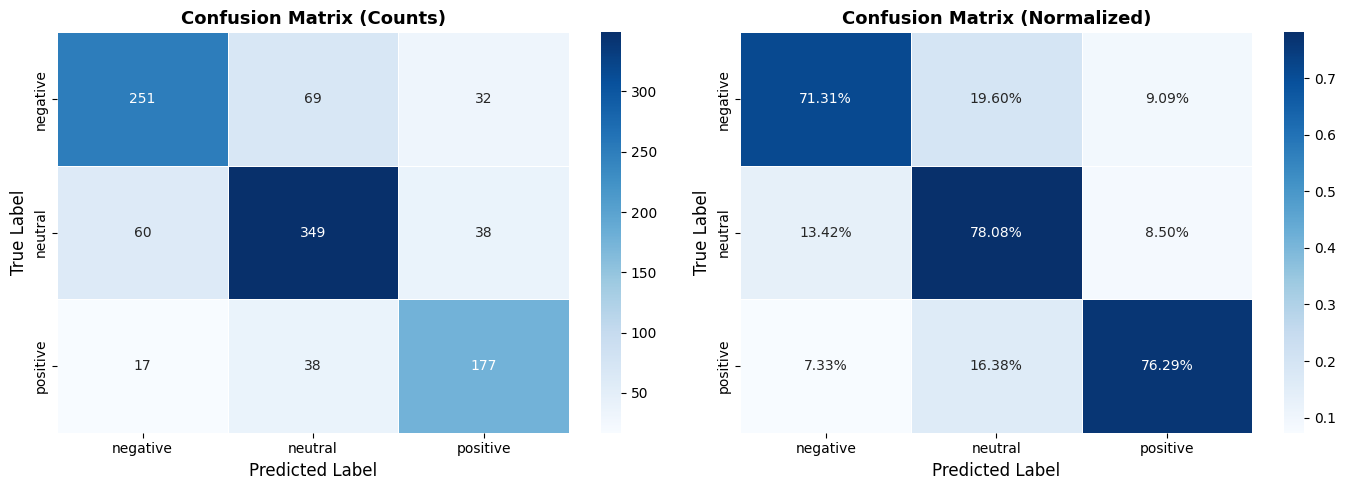

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
import pandas as pd

# 1. Run inference on the test set
predictions_output = trainer.predict(
    tokenized_test_dataset,
    ignore_keys=["past_key_values", "hidden_states", "attentions"]
)

logits = predictions_output.predictions
# Unwrap tuple output if the model returns auxiliary values alongside logits
if isinstance(logits, tuple):
    logits = logits[0]

labels = predictions_output.label_ids
preds  = np.argmax(logits, axis=-1)

# Convert logits to probabilities for AUC and confidence scoring
def softmax(x):
    e = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

probs = softmax(logits)

# 2. Core metrics 
class_names = ["negative", "neutral", "positive"]

print("=" * 60)
print("           TEST SET PERFORMANCE REPORT")
print("=" * 60)

# Per-class precision, recall, and F1
report = classification_report(labels, preds, target_names=class_names, digits=4)
print(report)

accuracy = (preds == labels).mean()
print(f"Overall Accuracy: {accuracy:.4f}")

# Macro AUC using one-vs-rest to handle the 3-class case
labels_bin = label_binarize(labels, classes=[0, 1, 2])
auc_score  = roc_auc_score(labels_bin, probs, multi_class="ovr", average="macro")
print(f"Macro AUC (OvR):  {auc_score:.4f}")

# 3. Confusion Matrix 
cm      = confusion_matrix(labels, preds)
# Normalize by true class totals to show per-class recall rates
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix (Counts)", "Confusion Matrix (Normalized)"],
    ["d", ".2%"],
):
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, ax=ax,
    )
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label",      fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

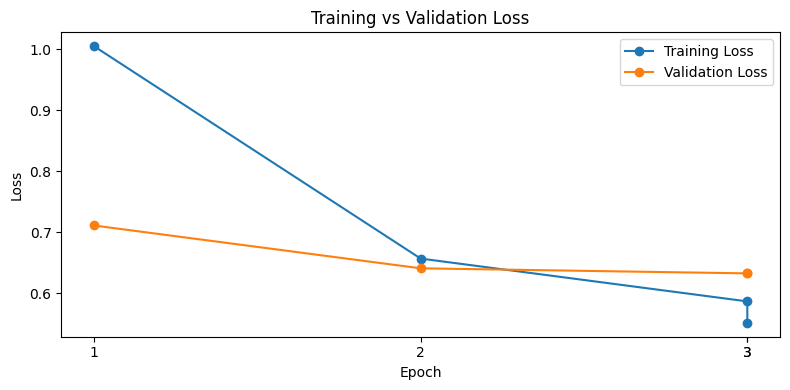

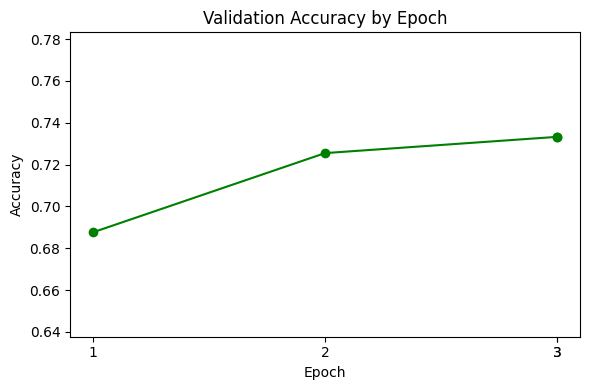

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Pull training and validation metrics from the trainer's log history
log_history = trainer.state.log_history

train_loss, val_loss, val_acc, epochs = [], [], [], []

for entry in log_history:
    if 'eval_loss' in entry:
        val_loss.append(entry['eval_loss'])
        val_acc.append(entry['eval_accuracy'])
        epochs.append(int(entry['epoch']))
    if 'loss' in entry and 'eval_loss' not in entry:
        train_loss.append(entry['loss'])

# Average training loss per epoch to match the validation loss granularity
steps_per_epoch      = len(train_loss) // len(epochs)
train_loss_per_epoch = [
    np.mean(train_loss[i * steps_per_epoch:(i + 1) * steps_per_epoch])
    for i in range(len(epochs))
]

# 1. Training vs Validation Loss 
plt.figure(figsize=(8, 4))
plt.plot(epochs, train_loss_per_epoch, marker='o', label='Training Loss')
plt.plot(epochs, val_loss,             marker='o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(epochs)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Validation Accuracy 
plt.figure(figsize=(6, 4))
plt.plot(epochs, val_acc, marker='o', color='green')
plt.title('Validation Accuracy by Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(epochs)
# Pad y-axis slightly around the observed range for readability
plt.ylim(max(0, min(val_acc) - 0.05), min(1.0, max(val_acc) + 0.05))
plt.tight_layout()
plt.show()

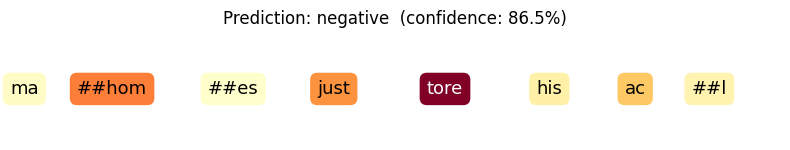

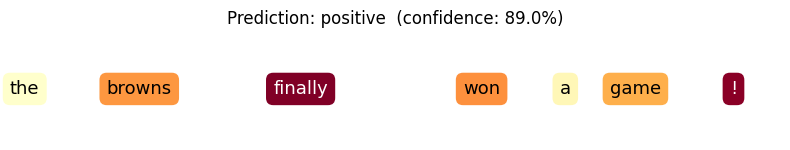

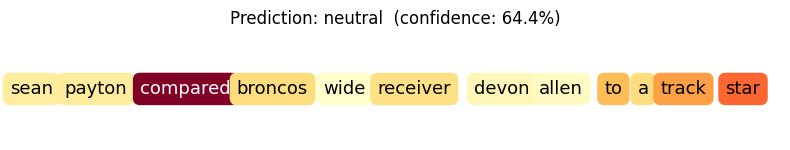

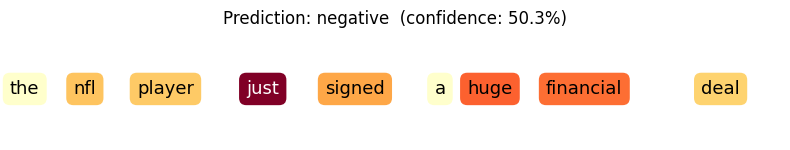

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def get_saliency(text, model, tokenizer, device):
    model.eval()
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)

    # Hook into the embedding layer to capture its output and gradients
    embedding_layer = model.distilbert.embeddings
    captured = {}

    def forward_hook(module, input, output):
        # Enable gradient tracking on the embedding output
        output.requires_grad_(True)
        output.retain_grad()
        captured['embeddings'] = output

    # Register and immediately remove the hook after the forward pass
    handle = embedding_layer.register_forward_hook(forward_hook)
    outputs = model(**inputs)
    handle.remove()

    # Backpropagate from the predicted class score to get embedding gradients
    predicted_class = outputs.logits.argmax(dim=-1).item()
    outputs.logits[0, predicted_class].backward()

    # Saliency = L2 norm of gradients across the embedding dimension per token
    saliency = captured['embeddings'].grad[0].norm(dim=-1).detach().cpu().numpy()
    tokens   = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())
    label    = id2label[predicted_class]
    score    = torch.softmax(outputs.logits, dim=-1)[0, predicted_class].item()

    return tokens, saliency, label, score


def plot_saliency(text, model, tokenizer, device):
    tokens, saliency, label, score = get_saliency(text, model, tokenizer, device)

    # Strip [CLS] and [SEP] special tokens before plotting
    tokens   = tokens[1:-1]
    saliency = saliency[1:-1]

    # Normalize saliency scores to [0, 1] for colormap mapping
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-9)

    fig, ax = plt.subplots(figsize=(max(8, len(tokens) * 0.6), 1.6))
    ax.axis('off')

    # Color each token by its saliency — darker = more influential
    cmap = plt.get_cmap("YlOrRd")
    x = 0
    for token, sal in zip(tokens, saliency):
        color = cmap(sal)
        # Switch to white text on high-saliency (dark) backgrounds for readability
        ax.text(x, 0.5, token, ha='left', va='center', fontsize=13,
                bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.4'),
                color='black' if sal < 0.7 else 'white')
        x += len(token) * 0.13 + 0.15

    ax.set_xlim(0, x)
    ax.set_ylim(0, 1)
    ax.set_title(f'Prediction: {label}  (confidence: {score:.1%})', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


# Test saliency on a negative, positive, and neutral NFL tweet
plot_saliency("Mahomes just tore his ACL", model, tokenizer, device)
plot_saliency("The Browns finally won a game!", model, tokenizer, device)
plot_saliency("Sean Payton compared Broncos wide receiver Devon Allen to a track star", model, tokenizer, device)
plot_saliency("The NFL player just signed a huge financial deal", model, tokenizer, device)

Red shows that the word is important

Extracting fine-tuned embeddings...
Done.
Running t-SNE on fine-tuned embeddings...


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Done.


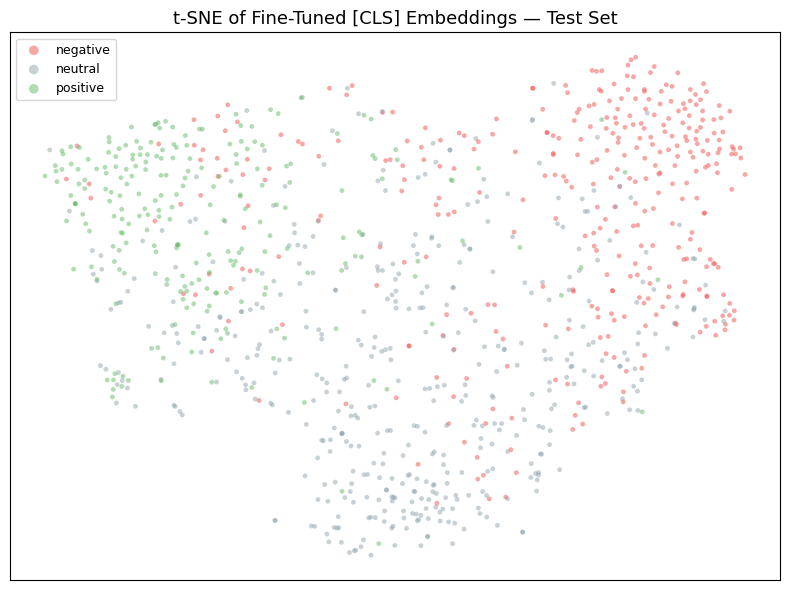

In [12]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import torch

# Step 1: Extract [CLS] embeddings for the full test set

def get_cls_embeddings(texts, model, tokenizer, device, batch_size=32):
    model.eval()
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i + batch_size]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True,
                           max_length=128, padding=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        # [CLS] token is the first token of the last hidden state
        cls_embeddings = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        all_embeddings.append(cls_embeddings)

    return np.vstack(all_embeddings)

# Enable hidden state output on the fine-tuned model
model.config.output_hidden_states = True

texts  = test_df["text"].tolist()
labels = test_df["sentiment"].tolist()

print("Extracting fine-tuned embeddings...")
ft_embeddings = get_cls_embeddings(texts, model, tokenizer, device)
print("Done.")

# Step 2: t-SNE 

# PCA to 50 dims first — speeds up t-SNE and reduces noise
print("Running t-SNE on fine-tuned embeddings...")
pca     = PCA(n_components=50, random_state=42)
reduced = pca.fit_transform(ft_embeddings)
ft_2d   = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000).fit_transform(reduced)
print("Done.")

# Step 3: Plot 

label_colors = {"negative": "#ef5350", "neutral": "#90a4ae", "positive": "#66bb6a"}
label_array  = np.array(labels)

plt.figure(figsize=(8, 6))
for sentiment, color in label_colors.items():
    mask = label_array == sentiment
    plt.scatter(ft_2d[mask, 0], ft_2d[mask, 1],
                c=color, label=sentiment, alpha=0.5, s=12, edgecolors='none')

plt.title("t-SNE of Fine-Tuned [CLS] Embeddings — Test Set", fontsize=13)
plt.xticks([])
plt.yticks([])
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()